In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
df = pd.read_csv("deforestation_dataset.csv")

df.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [56]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    str    
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incidents      1

,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
count,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,1973.900000,2402.040000,5.581324,249.780000,1989.065675,4.669843e+07,2522.261399,34.699672,2.580000,47.242961,248.17000,101.590000,17.440189
std,30.521561,1289.357713,2.486552,131.947233,580.739902,2.821265e+07,1428.257175,14.939793,1.147505,28.615151,144.81699,60.859516,7.747759
min,1925.000000,503.000000,1.535528,18.000000,1012.352137,1.882729e+06,66.692280,10.735281,1.000000,0.142865,0.00000,2.000000,5.259525
25%,1946.750000,1288.500000,3.409892,142.750000,1519.817401,2.353557e+07,1331.429568,22.341474,2.000000,27.492684,121.25000,55.500000,10.274762
50%,1972.500000,2159.000000,5.540553,257.000000,1875.424360,4.422406e+07,2517.956363,33.265582,3.000000,43.281263,255.00000,95.500000,17.969884
75%,1997.250000,3495.500000,7.642558,358.500000,2543.170733,7.114959e+07,3694.946835,48.173119,4.000000,72.924698,344.50000,159.250000,24.439923
max,2023.000000,4949.000000,9.791851,484.000000,2984.602077,9.783425e+07,4902.380882,59.666082,4.000000,99.492284,499.00000,199.000000,29.944121


In [57]:
df = df.fillna(df.mean(numeric_only=True))

In [58]:
le = LabelEncoder()

categorical_cols = [
    "Deforestation_Policy_Strictness",
    "Corruption_Index"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

In [59]:
target = "Tree_Cover_Loss_percent"   # better behaved target

X = df.drop([target, "Country"], axis=1)
y = df[target]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVR(kernel="linear")

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Baseline MAE:", mae)
print("Baseline MSE:", mse)
print("Baseline RMSE:", rmse)
print("Baseline R2:", r2)

Baseline MAE: 1.9805354412044704
Baseline MSE: 5.244892506302407
Baseline RMSE: 2.290173029773604
Baseline R2: -0.09771961685905395


In [63]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_grid = {
    "svr__kernel": ["rbf", "poly"],
    "svr__C": [0.1, 1, 10, 100],
    "svr__gamma": ["scale", "auto", 0.01, 0.001],
    "svr__epsilon": [0.1, 0.5, 1]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 'scale', 'svr__kernel': 'poly'}


In [69]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("----- Tuned SVM Model Performance -----")
print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R2 Score:", r2_best)

----- Tuned SVM Model Performance -----
MAE: 2.1034421405130668
MSE: 5.267678583910723
RMSE: 2.2951423885917674
R2 Score: -0.1024885848315844


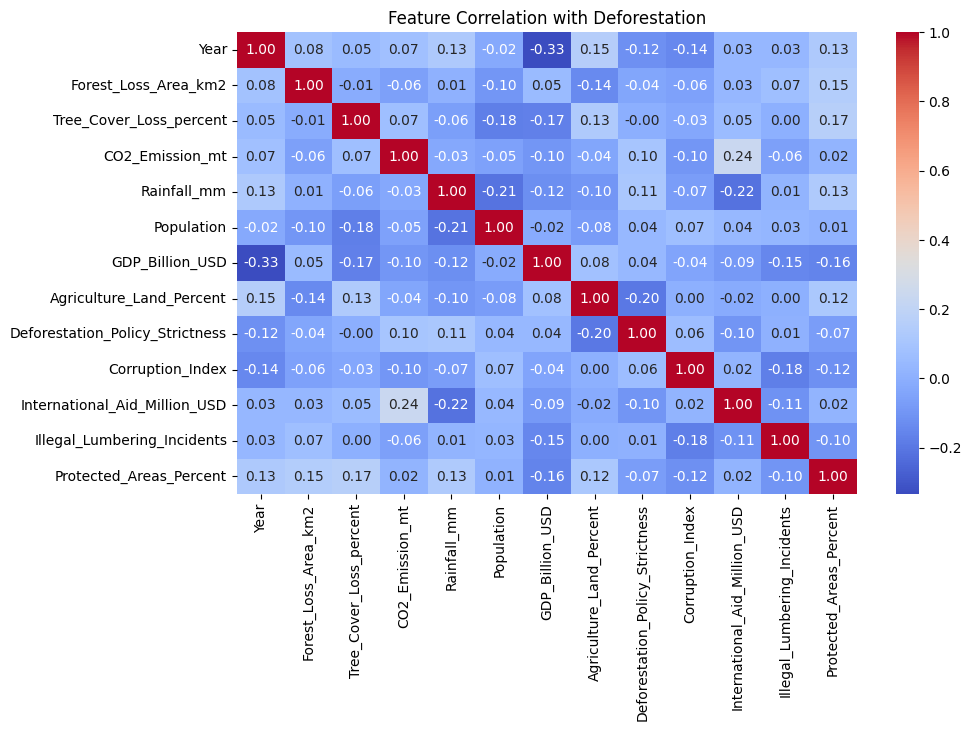

In [65]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation with Deforestation")

plt.show()

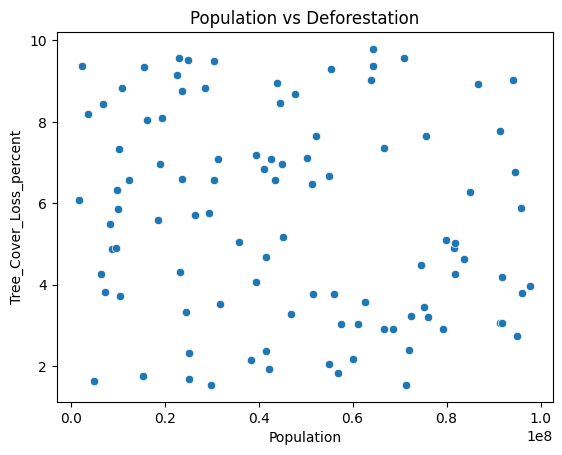

In [66]:
sns.scatterplot(
    x="Population",
    y=target,
    data=df
)

plt.title("Population vs Deforestation")
plt.show()

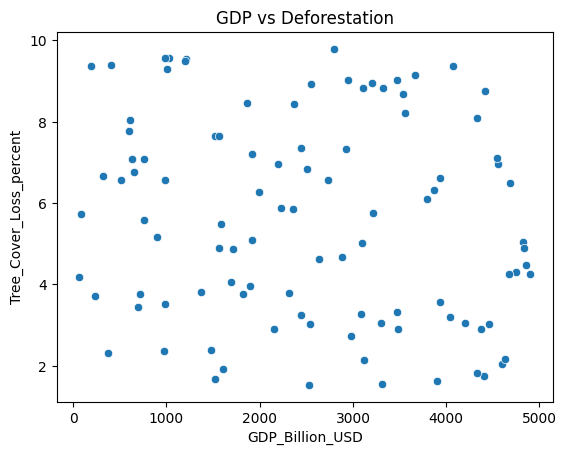

In [67]:
sns.scatterplot(
    x="GDP_Billion_USD",
    y=target,
    data=df
)

plt.title("GDP vs Deforestation")
plt.show()

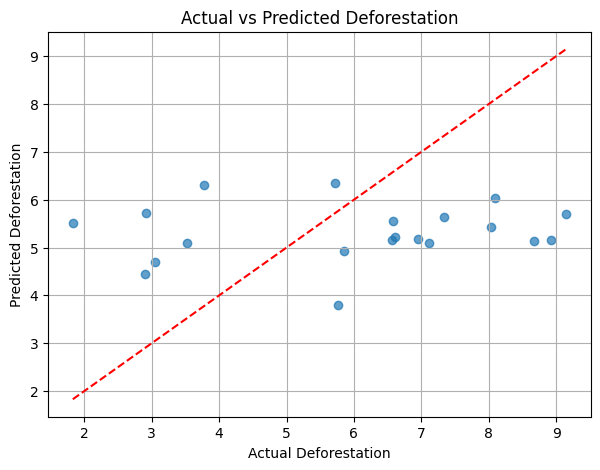

In [70]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_best, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Deforestation")
plt.ylabel("Predicted Deforestation")
plt.title("Actual vs Predicted Deforestation")

plt.grid(True)

plt.show()

## Evaluation and Validation of the SVM Model

In this phase, the performance of the Support Vector Machine (SVM) model is evaluated using several regression evaluation metrics. The goal of this evaluation is to measure how accurately the model predicts deforestation levels based on the environmental, economic, and policy-related features in the dataset.

The model predictions were compared with the actual deforestation values to determine the effectiveness of the trained model.

---

## Evaluation Metrics

The following evaluation metrics were used to assess the performance of the model.

### Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between the predicted and actual values. It provides an indication of the average magnitude of prediction errors without considering their direction.

A lower MAE value indicates better model performance.

---

### Mean Squared Error (MSE)

Mean Squared Error measures the average squared difference between predicted and actual values. Squaring the error values gives more weight to larger errors.

Lower MSE values indicate that the predictions are closer to the actual values.

---

### Root Mean Squared Error (RMSE)

Root Mean Squared Error is the square root of the Mean Squared Error. RMSE provides the error value in the same unit as the target variable, making it easier to interpret the magnitude of prediction errors.

A smaller RMSE value indicates better predictive accuracy.

---

### R² Score

The R² score (coefficient of determination) measures how well the model explains the variance in the target variable. It indicates the proportion of variance in the dependent variable that is predictable from the independent variables.

An R² value closer to 1 indicates a better fit of the model.

---

## Visualization and Model Validation

To further validate the model performance, several visualizations were generated.

### Correlation Heatmap

A correlation heatmap was created to analyze the relationships between the variables in the dataset. This visualization helps in identifying how strongly each feature is related to deforestation levels.

The heatmap shows that most variables have relatively weak correlations with deforestation, which may affect the predictive performance of the model.

---

### Population vs Deforestation

A scatter plot was generated to examine the relationship between population size and deforestation levels.

The distribution of points indicates that population does not show a strong direct relationship with forest loss in the dataset.

---

### GDP vs Deforestation

Another scatter plot was used to analyze the relationship between GDP and deforestation levels.

The results suggest that economic development alone does not strongly determine deforestation patterns, indicating that other environmental or policy factors may influence forest loss.

---

### Actual vs Predicted Deforestation

The final validation plot compares the actual deforestation values with the predicted values produced by the SVM model.

If the model predictions are accurate, the predicted values should closely align with the actual values. Differences between the two indicate prediction errors.

This visualization helps in understanding how well the model generalizes to unseen data.

---

## Key Insights

Based on the evaluation results and visual analysis, several observations can be made:

- The relationships between many variables and deforestation levels appear relatively weak.
- Population and GDP do not show strong direct correlations with forest loss in the dataset.
- Environmental and policy-related variables may have a greater influence on deforestation patterns.
- The SVM model is able to generate predictions, but the overall predictive performance is limited due to weak correlations between features.

---

## Conclusion

The Support Vector Machine (SVM) model was implemented to analyze and predict deforestation patterns using environmental and socio-economic indicators.

The evaluation metrics and visual analysis indicate that while the model can generate predictions, the predictive performance is influenced by the limited strength of relationships between the input features and deforestation levels.

This analysis demonstrates how machine learning techniques can be applied to environmental datasets to explore patterns and relationships related to deforestation.

Further improvements could include incorporating additional environmental variables and larger datasets to enhance model accuracy and predictive capability.